In [28]:
import copy
import datetime as dt
from datetime import datetime
import importlib  # needed so that we can reload packages
import logging
import os
import pathlib
import sys
import time
import warnings
from typing import Union, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.logger_utils import setup_clean_logger, mute_external_loggers

# SISEPUEDE imports
from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
import sisepuede.core.support_classes as sc
import sisepuede.transformers as trf
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.visualization.plots as svp

# --- Runtime configuration ---
warnings.filterwarnings("ignore")

# Set up a clean logger for your notebook
logger = setup_clean_logger("notebook", logging.INFO)
logger.info("Notebook started successfully.")

# Mute logs from sisepuede to avoid duplication
mute_external_loggers(["sisepuede"])


2026-04-02 17:50:05,245 - INFO - Notebook started successfully.


In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Initial Set up

Make sure to edit the config yaml under ssp_modeling/config_files/config.yaml

You can also create a new config yaml



In [30]:
# Set up dir paths

CURR_DIR_PATH = pathlib.Path(os.getcwd())
SSP_MODELING_DIR_PATH = CURR_DIR_PATH.parent
PROJECT_DIR_PATH = SSP_MODELING_DIR_PATH.parent
DATA_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("input_data")
RUN_OUTPUT_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("ssp_run_output")
SCENARIO_MAPPING_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("scenario_mapping")
CONFIG_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("config_files")
TRANSFORMATIONS_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("transformations")
MISC_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("misc")
STRATEGIES_DEFINITIONS_FILE_PATH = TRANSFORMATIONS_DIR_PATH.joinpath("strategy_definitions.csv")
STRATEGY_MAPPING_FILE_PATH = MISC_DIR_PATH.joinpath("strategy_mapping.yaml")
ASSUMPTIONS_PATH = SSP_MODELING_DIR_PATH.joinpath("assumptions")

In [31]:
from ssp_transformations_handler.GeneralUtils import GeneralUtils
from ssp_transformations_handler.TransformationUtils import TransformationYamlProcessor, StrategyCSVHandler

# Initialize general utilities
g_utils = GeneralUtils()

In [32]:
# Load config file, double check your parameters are correct

YAML_FILE_PATH = os.path.join(CONFIG_DIR_PATH, "config.yaml")
config_params = g_utils.read_yaml(YAML_FILE_PATH)

country_name = config_params['country_name']
ssp_input_file_name = config_params['ssp_input_file_name']
ssp_transformation_cw = config_params['ssp_transformation_cw']
energy_model_flag = config_params['energy_model_flag']
set_lndu_reallocation_factor_to_zero_flag = config_params['set_lndu_reallocation_factor_to_zero']

# Print config parameters
logger.info(f"Country name: {country_name}")
logger.info(f"SSP input file name: {ssp_input_file_name}")
logger.info(f"SSP transformation CW: {ssp_transformation_cw}")
logger.info(f"Energy model flag: {energy_model_flag}")
logger.info(f"Set lndu reallocation factor to zero flag: {set_lndu_reallocation_factor_to_zero_flag}")

2026-04-02 17:50:05,298 - INFO - Country name: mexico
2026-04-02 17:50:05,299 - INFO - SSP input file name: sisepuede_adj_inputs_MEX.csv
2026-04-02 17:50:05,299 - INFO - SSP transformation CW: ssp_mexico_transformation_strategy_pemex_vf.xlsx
2026-04-02 17:50:05,299 - INFO - Energy model flag: True
2026-04-02 17:50:05,299 - INFO - Set lndu reallocation factor to zero flag: True


In [33]:
def get_file_structure(
    y0: int = 2015,
    y1: int = 2060,
) -> Tuple[sfs.SISEPUEDEFileStructure, att.AttributeTable]:
    """Get the SISEPUEDE File Structure and update the attribute table
        with new years.
    """
    # setup some SISEPUEDE variables and update time period
    file_struct = sfs.SISEPUEDEFileStructure(
        initialize_directories = False,
    )
 
    # get some keys
    key_time_period = file_struct.model_attributes.dim_time_period
    key_year = file_struct.model_attributes.field_dim_year
 
 
    ##  BUILD THE ATTRIBUTE AND UPDATE
 
    # setup the new attribute table
    years = np.arange(y0, y1 + 1, ).astype(int)
    attribute_time_period = att.AttributeTable(
        pd.DataFrame(
            {
                key_time_period: range(len(years)),
                key_year: years,
            }
        ),
        key_time_period,
    )
 
    # finally, update the ModelAttributes inside the file structure
    (
        file_struct
        .model_attributes
        .update_dimensional_attribute_table(
            attribute_time_period,
        )
    )
 
    # return the tuple
    out = (file_struct, attribute_time_period, )
 
    return out
 
# # setup models
# models = sm.SISEPUEDEModels(
#     matt,
#     allow_electricity_run = True,
#     fp_julia = _FILE_STRUCTURE.dir_jl,
#     fp_nemomod_reference_files = _FILE_STRUCTURE.dir_ref_nemo,
#     initialize_julia = True, 
# )

In [34]:
# Set up SSP objects
INPUT_FILE_PATH = DATA_DIR_PATH.joinpath(ssp_input_file_name)

# model attributes and associated support classes
_EXAMPLES = sxl.SISEPUEDEExamples()
_FILE_STRUCTURE, _ATTRIBUTE_TABLE_TIME_PERIOD = get_file_structure()
matt = _FILE_STRUCTURE.model_attributes
regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )

### Making sure our input file has the correct format and correct columns
We use an example df with the complete fields and correct format to make sure our file is in the right shape

In [35]:
INPUT_FILE_PATH

PosixPath('/Users/fabianfuentes/git/ssp_mexico/ssp_modeling/input_data/sisepuede_adj_inputs_MEX.csv')

In [36]:
##  BUILD BASE INPUTS
df_inputs_raw = pd.read_csv(INPUT_FILE_PATH)

# pull example data to fill in gaps
df_example_input = _EXAMPLES("input_data_frame")

In [37]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw)

Columns in df_example but not in df_input: set()
Columns in df_input but not in df_example: {'iso_alpha_3', 'year'}


In [38]:
# Ensure if time_period field exist
if 'time_period' not in df_inputs_raw.columns:
    logger.info("Adding 'time_period' column to df_inputs_raw")
    df_inputs_raw = df_inputs_raw.rename(columns={'period':'time_period'})
else:
    logger.info("'time_period' column already exists in df_inputs_raw")

2026-04-02 17:50:06,020 - INFO - 'time_period' column already exists in df_inputs_raw


In [39]:
# Fixes differences and makes sure that our df is in the correct format.
# Note: Edit this if you need more changes in your df

df_inputs_raw_complete = g_utils.add_missing_cols(df_example_input, df_inputs_raw.copy())
df_inputs_raw_complete.head()

No missing columns to add.


,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_geothermal,nemomod_entc_scalar_availability_factor_pp_hydropower,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3,region
0,2015,0,0,0.000264,0,3.660000e-08,1.400000e-07,0.729069,0.729069,0.729069,...,1,1,1,1,0.75,1,1,1.0,MEX,mexico
1,2016,0,0,0.000265,0,3.980000e-08,1.570000e-07,0.729069,0.729069,0.729069,...,1,1,1,1,0.75,1,1,1.0,MEX,mexico
2,2017,0,0,0.000266,0,3.640000e-08,1.620000e-07,0.729069,0.729069,0.729069,...,1,1,1,1,0.75,1,1,1.0,MEX,mexico
3,2018,0,0,0.000265,0,3.610000e-08,1.610000e-07,0.729069,0.729069,0.729069,...,1,1,1,1,0.75,1,1,1.0,MEX,mexico
4,2019,0,0,0.000265,0,3.460000e-08,1.640000e-07,0.729069,0.729069,0.729069,...,1,1,1,1,0.75,1,1,1.0,MEX,mexico


In [40]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw_complete)

Columns in df_example but not in df_input: set()
Columns in df_input but not in df_example: {'iso_alpha_3', 'year'}


In [41]:
# check region field
df_inputs_raw_complete['region'].unique()

array(['mexico'], dtype=object)

In [42]:
# Set region to country name
df_inputs_raw_complete['region'] = country_name
df_inputs_raw_complete['region'].head()

0    mexico
1    mexico
2    mexico
3    mexico
4    mexico
Name: region, dtype: object

In [43]:
df_inputs_raw_complete = df_inputs_raw_complete[df_inputs_raw_complete['time_period'].between(0, 45)]
df_inputs_raw_complete['time_period'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [44]:
cost_enfu = [x for x in df_inputs_raw_complete.columns if ("cost_enfu_" in x) ]
df_inputs_raw_complete[cost_enfu].iloc[1]

cost_enfu_fuel_biomass_usd_per_tonne                    2.097800e+02
cost_enfu_fuel_coal_usd_per_tonne                       1.005975e+02
cost_enfu_fuel_coke_usd_per_tonne                       1.877075e+02
cost_enfu_fuel_nuclear_usd_per_tonne                    1.663000e+06
cost_enfu_fuel_biogas_usd_per_mmbtu                     2.200000e+01
cost_enfu_fuel_electricity_usd_per_mmbtu                5.145872e+01
cost_enfu_fuel_hydrocarbon_gas_liquids_usd_per_mmbtu    1.875801e+02
cost_enfu_fuel_hydrogen_usd_per_mmbtu                   8.654041e+01
cost_enfu_fuel_natural_gas_usd_per_mmbtu                2.872968e+00
cost_enfu_fuel_waste_usd_per_mmbtu                      9.380000e+03
cost_enfu_fuel_biofuels_usd_per_m3                      5.210903e+02
cost_enfu_fuel_crude_usd_per_m3                         4.451295e+02
cost_enfu_fuel_diesel_usd_per_m3                        1.483750e+03
cost_enfu_fuel_furnace_gas_usd_per_m3                   1.372565e+04
cost_enfu_fuel_gasoline_usd_per_m3

<Axes: >

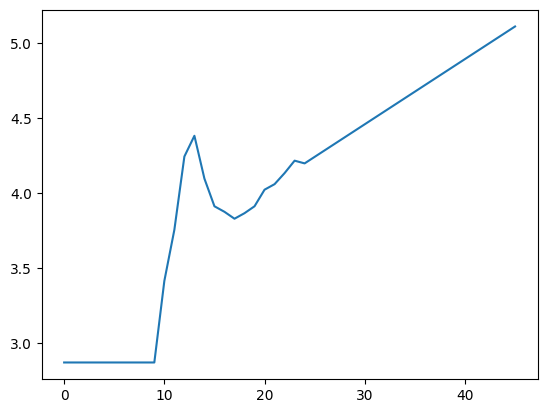

In [45]:
df_inputs_raw_complete['cost_enfu_fuel_natural_gas_usd_per_mmbtu'].plot()

In [46]:
df_inputs_raw_complete[cost_enfu].iloc[1]

cost_enfu_fuel_biomass_usd_per_tonne                    2.097800e+02
cost_enfu_fuel_coal_usd_per_tonne                       1.005975e+02
cost_enfu_fuel_coke_usd_per_tonne                       1.877075e+02
cost_enfu_fuel_nuclear_usd_per_tonne                    1.663000e+06
cost_enfu_fuel_biogas_usd_per_mmbtu                     2.200000e+01
cost_enfu_fuel_electricity_usd_per_mmbtu                5.145872e+01
cost_enfu_fuel_hydrocarbon_gas_liquids_usd_per_mmbtu    1.875801e+02
cost_enfu_fuel_hydrogen_usd_per_mmbtu                   8.654041e+01
cost_enfu_fuel_natural_gas_usd_per_mmbtu                2.872968e+00
cost_enfu_fuel_waste_usd_per_mmbtu                      9.380000e+03
cost_enfu_fuel_biofuels_usd_per_m3                      5.210903e+02
cost_enfu_fuel_crude_usd_per_m3                         4.451295e+02
cost_enfu_fuel_diesel_usd_per_m3                        1.483750e+03
cost_enfu_fuel_furnace_gas_usd_per_m3                   1.372565e+04
cost_enfu_fuel_gasoline_usd_per_m3

## Adj capital cost_pp

In [47]:
nemomod_entc_capital_cost_pp = [x for x in df_inputs_raw_complete.columns if ("nemomod_entc_capital_" in x) ]
df_inputs_raw_complete[nemomod_entc_capital_cost_pp].iloc[1]

nemomod_entc_capital_cost_pp_biogas_mm_usd_per_gw                       2581.866715
nemomod_entc_capital_cost_pp_biomass_mm_usd_per_gw                      3043.500000
nemomod_entc_capital_cost_pp_coal_mm_usd_per_gw                         3393.583333
nemomod_entc_capital_cost_pp_gas_mm_usd_per_gw                           695.666667
nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw                  11905.666670
nemomod_entc_capital_cost_pp_hydropower_mm_usd_per_gw                   3887.969444
nemomod_entc_capital_cost_pp_nuclear_mm_usd_per_gw                      5153.583333
nemomod_entc_capital_cost_pp_ocean_mm_usd_per_gw                       30495.041960
nemomod_entc_capital_cost_pp_oil_mm_usd_per_gw                          1204.871134
nemomod_entc_capital_cost_pp_solar_mm_usd_per_gw                         984.250000
nemomod_entc_capital_cost_pp_waste_incineration_mm_usd_per_gw           3872.800073
nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw                         1125

<Axes: >

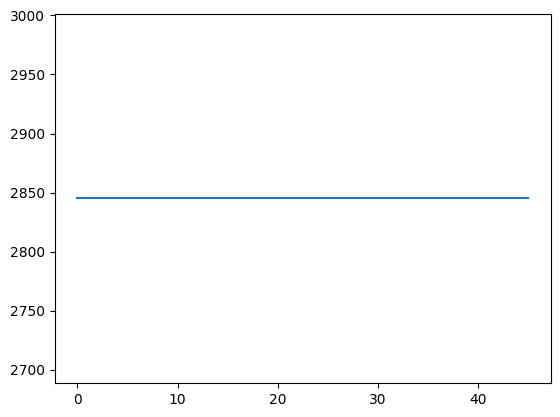

In [48]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_gas_ccs_mm_usd_per_gw'].plot()

In [49]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_gas_ccs_mm_usd_per_gw'] = 2845 *1.1
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_gas_ccs_mm_usd_per_gw'].iloc[0]

np.float64(3129.5000000000005)

In [50]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_solar_mm_usd_per_gw'] = 750/984.25 *df_inputs_raw_complete['nemomod_entc_capital_cost_pp_solar_mm_usd_per_gw']
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_solar_mm_usd_per_gw'].iloc[1]

np.float64(750.0)

In [51]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw'] = 3500/11905.666667 *df_inputs_raw_complete['nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw']
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw'].iloc[1]

np.float64(3500.0000008819334)

In [52]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw'] = 1300/3209.722222 *df_inputs_raw_complete['nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw']
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw'].iloc[1]

np.float64(455.6469061328012)

In [53]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_hydropower_mm_usd_per_gw'] = 2500/3887.969444 *df_inputs_raw_complete['nemomod_entc_capital_cost_pp_hydropower_mm_usd_per_gw']
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_hydropower_mm_usd_per_gw'].iloc[1]

np.float64(2500.0)

In [54]:
df_inputs_raw_complete[nemomod_entc_capital_cost_pp].iloc[1]

nemomod_entc_capital_cost_pp_biogas_mm_usd_per_gw                       2581.866715
nemomod_entc_capital_cost_pp_biomass_mm_usd_per_gw                      3043.500000
nemomod_entc_capital_cost_pp_coal_mm_usd_per_gw                         3393.583333
nemomod_entc_capital_cost_pp_gas_mm_usd_per_gw                           695.666667
nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw                   3500.000001
nemomod_entc_capital_cost_pp_hydropower_mm_usd_per_gw                   2500.000000
nemomod_entc_capital_cost_pp_nuclear_mm_usd_per_gw                      5153.583333
nemomod_entc_capital_cost_pp_ocean_mm_usd_per_gw                       30495.041960
nemomod_entc_capital_cost_pp_oil_mm_usd_per_gw                          1204.871134
nemomod_entc_capital_cost_pp_solar_mm_usd_per_gw                         750.000000
nemomod_entc_capital_cost_pp_waste_incineration_mm_usd_per_gw           3872.800073
nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw                          455

In [59]:
df_inputs_raw_complete[['time_period'] + nemomod_entc_capital_cost_pp].head()

,time_period,nemomod_entc_capital_cost_pp_biogas_mm_usd_per_gw,nemomod_entc_capital_cost_pp_biomass_mm_usd_per_gw,nemomod_entc_capital_cost_pp_coal_mm_usd_per_gw,nemomod_entc_capital_cost_pp_gas_mm_usd_per_gw,nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw,nemomod_entc_capital_cost_pp_hydropower_mm_usd_per_gw,nemomod_entc_capital_cost_pp_nuclear_mm_usd_per_gw,nemomod_entc_capital_cost_pp_ocean_mm_usd_per_gw,nemomod_entc_capital_cost_pp_oil_mm_usd_per_gw,...,nemomod_entc_capital_cost_pp_waste_incineration_mm_usd_per_gw,nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw,nemomod_entc_capital_cost_fp_hydrogen_electrolysis_mm_usd_per_gw,nemomod_entc_capital_cost_fp_hydrogen_gasification_mm_usd_per_gw,nemomod_entc_capital_cost_fp_hydrogen_reformation_mm_usd_per_gw,nemomod_entc_capital_cost_pp_coal_ccs_mm_usd_per_gw,nemomod_entc_capital_cost_pp_gas_ccs_mm_usd_per_gw,nemomod_entc_capital_cost_fp_ammonia_production_mm_usd_per_gw,nemomod_entc_capital_cost_fp_hydrogen_reformation_ccs_mm_usd_per_gw,nemomod_entc_capital_cost_fp_natural_gas_liquefaction_mm_usd_per_gw
0,0,2581.866715,3043.5,3393.583333,695.666667,3500.000001,2500.0,5153.583333,30495.04196,1204.871134,...,3872.800073,455.646906,1200,800,800,6625,3129.5,0,1200,783.704221
1,1,2581.866715,3043.5,3393.583333,695.666667,3500.000001,2500.0,5153.583333,30495.04196,1204.871134,...,3872.800073,455.646906,1200,800,800,6625,3129.5,0,1200,783.704221
2,2,2581.866715,3043.5,3393.583333,695.666667,3500.000001,2500.0,5153.583333,30495.04196,1204.871134,...,3872.800073,455.646906,1200,800,800,6625,3129.5,0,1200,783.704221
3,3,2581.866715,3043.5,3393.583333,695.666667,3500.000001,2500.0,5153.583333,30495.04196,1204.871134,...,3872.800073,455.646906,1200,800,800,6625,3129.5,0,1200,783.704221
4,4,2581.866715,3043.5,3393.583333,695.666667,3500.000001,2500.0,5153.583333,30495.04196,1204.871134,...,3872.800073,455.646906,1200,800,800,6625,3129.5,0,1200,783.704221


In [60]:
ASSUMPTIONS_PATH

PosixPath('/Users/fabianfuentes/git/ssp_mexico/ssp_modeling/assumptions')

In [61]:
df_inputs_raw_complete[['time_period'] + nemomod_entc_capital_cost_pp].to_csv(ASSUMPTIONS_PATH.joinpath("mexico_entc_capital_cost_pp.csv"), index=False)

## EPM changes

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_solar_mm_usd_per_gw'].plot()   

In [ ]:
var = "nemomod_entc_capital_cost_pp_solar_mm_usd_per_gw"
yr0 = 2024
yr1 = 2060

# EPM Solar
fac_raw = {
    2024: 1.0,
    2025: 1.0,
    2026: 1.0,
    2028: 0.894673123,
    2030: 0.789346247,
    2032: 0.765133172,
    2034: 0.739709443,
    2036: 0.715496368,
    2038: 0.691283293,
    2040: 0.665859564,
    2045: 0.604116223,
    2050: 0.542372881,
    2055: 0.542372881,
    2060: 0.542372881,
}

years = np.arange(yr0, yr1 + 1)

# Build full annual factor vector + interpolate missing years
fac = (
    pd.Series(fac_raw, dtype="float64")
      .reindex(years)
      .interpolate(method="linear")
      .ffill()
      .bfill()
)
base = df_inputs_raw_complete.loc[df_inputs_raw_complete["year"] == yr0, var].iloc[0]

m = (df_inputs_raw_complete["year"] >= yr0) & (df_inputs_raw_complete["year"] <= yr1)
df_inputs_raw_complete.loc[m, var] = df_inputs_raw_complete.loc[m, "year"].map(fac).to_numpy() * base            

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_solar_mm_usd_per_gw'].plot() 

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw'].plot()

In [ ]:
var = "nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw"
yr0 = 2024
yr1 = 2060

# EPM Geothermal
fac_raw = {
    2024: 1.0, 
    2025: 1.0, 
    2026: 1.0,
    2028: 0.973628692,
    2030: 0.946202532,
        2032: 0.936708861,
        2034: 0.92721519,
        2036: 0.917721519,
        2038: 0.9092827,
        2040: 0.89978903,
        2045: 0.877637131,
        2050: 0.855485232,
        2055: 0.855485232,
        2060: 0.855485232
}

years = np.arange(yr0, yr1 + 1)

# Build full annual factor vector + interpolate missing years
fac = (
    pd.Series(fac_raw, dtype="float64")
      .reindex(years)
      .interpolate(method="linear")
      .ffill()
      .bfill()
)
base = df_inputs_raw_complete.loc[df_inputs_raw_complete["year"] == yr0, var].iloc[0]

m = (df_inputs_raw_complete["year"] >= yr0) & (df_inputs_raw_complete["year"] <= yr1)
df_inputs_raw_complete.loc[m, var] = df_inputs_raw_complete.loc[m, "year"].map(fac).to_numpy() * base            

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_geothermal_mm_usd_per_gw'].plot()

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_biomass_mm_usd_per_gw'].plot()

In [ ]:
var = "nemomod_entc_capital_cost_pp_biomass_mm_usd_per_gw"
yr0 = 2024
yr1 = 2060

# EPM Biosmass
fac_raw = {
    2024: 1.0, 
    2025: 1.0, 
    2026: 1.0,
        2028: 0.987679671,
        2030: 0.974332649,
        2032: 0.960985626,
        2034: 0.948665298,
        2036: 0.935318275,
        2038: 0.921971253,
        2040: 0.90862423,
        2045: 0.876796715,
        2050: 0.843942505,
        2055: 0.843942505,
        2060: 0.843942505,
}

years = np.arange(yr0, yr1 + 1)

# Build full annual factor vector + interpolate missing years
fac = (
    pd.Series(fac_raw, dtype="float64")
      .reindex(years)
      .interpolate(method="linear")
      .ffill()
      .bfill()
)
base = df_inputs_raw_complete.loc[df_inputs_raw_complete["year"] == yr0, var].iloc[0]

m = (df_inputs_raw_complete["year"] >= yr0) & (df_inputs_raw_complete["year"] <= yr1)
df_inputs_raw_complete.loc[m, var] = df_inputs_raw_complete.loc[m, "year"].map(fac).to_numpy() * base            

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_biomass_mm_usd_per_gw'].plot()

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_gas_ccs_mm_usd_per_gw'].plot()

In [ ]:
var = "nemomod_entc_capital_cost_pp_gas_ccs_mm_usd_per_gw"
yr0 = 2024
yr1 = 2060

# EPM GasCCS
fac_raw = {
    2024: 1.0, 
    2025: 1.0, 
    2026: 1.0,
        2028: 0.96956978,
        2030: 0.942287513,
        2032: 0.916054565,
        2034: 0.88772298,
        2036: 0.858342078,
        2038: 0.828961175,
        2040: 0.815320042,
        2045: 0.778593914,
        2050: 0.74501574,
        2055: 0.74501574,
        2060: 0.74501574,
}

years = np.arange(yr0, yr1 + 1)

# Build full annual factor vector + interpolate missing years
fac = (
    pd.Series(fac_raw, dtype="float64")
      .reindex(years)
      .interpolate(method="linear")
      .ffill()
      .bfill()
)
base = df_inputs_raw_complete.loc[df_inputs_raw_complete["year"] == yr0, var].iloc[0]

m = (df_inputs_raw_complete["year"] >= yr0) & (df_inputs_raw_complete["year"] <= yr1)
df_inputs_raw_complete.loc[m, var] = df_inputs_raw_complete.loc[m, "year"].map(fac).to_numpy() * base            

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_gas_ccs_mm_usd_per_gw'].plot()

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw'].plot()

In [ ]:
var = "nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw"
yr0 = 2024
yr1 = 2060

# EPM Wind_High
fac_raw = {
    2024: 1.0, 
    2025: 1.0, 
    2026: 1.0,
        2028: 0.984552008,
        2030: 0.970133883,
        2032: 0.963954686,
        2034: 0.957775489,
        2036: 0.952626159,
        2038: 0.946446962,
        2040: 0.941297631,
        2045: 0.926879506,
        2050: 0.91246138,
        2055: 0.91246138,
        2060: 0.91246138,
}

years = np.arange(yr0, yr1 + 1)

# Build full annual factor vector + interpolate missing years
fac = (
    pd.Series(fac_raw, dtype="float64")
      .reindex(years)
      .interpolate(method="linear")
      .ffill()
      .bfill()
)
base = df_inputs_raw_complete.loc[df_inputs_raw_complete["year"] == yr0, var].iloc[0]

m = (df_inputs_raw_complete["year"] >= yr0) & (df_inputs_raw_complete["year"] <= yr1)
df_inputs_raw_complete.loc[m, var] = df_inputs_raw_complete.loc[m, "year"].map(fac).to_numpy() * base            

In [ ]:
df_inputs_raw_complete['nemomod_entc_capital_cost_pp_wind_mm_usd_per_gw'].plot()

## Let's Modify the  LNDU Reallocation factor

In [ ]:
if set_lndu_reallocation_factor_to_zero_flag:
    df_inputs_raw_complete['lndu_reallocation_factor'] = 0

df_inputs_raw_complete['lndu_reallocation_factor'].mean()

#  Let's try building transformations using this


In [ ]:
transformers = trf.transformers.Transformers(
    {},
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = df_inputs_raw_complete,
)

##  Instantiate some transformations. Make sure to run this cell to create the transformations folder for the first time or if you wish to overwrite

In [ ]:
# set an ouput path and instantiate
if not TRANSFORMATIONS_DIR_PATH.exists():
    trf.instantiate_default_strategy_directory(
        transformers,
        TRANSFORMATIONS_DIR_PATH,
    )
else:
    logger.info(f"Directory {TRANSFORMATIONS_DIR_PATH} already exists. Skipping instantiation.")


##  --HERE, CUSTOMIZE YOUR TRANSFORMATIONS AND STRATEGIES--

### Customizing transformations and strategies files using TransformationUtils.py classes

In [ ]:
# Generate new transformation files based on the excel mapping file. 
# Make sure to have the most updated format for the excel file, check the one used in this notebook for reference.

if ssp_transformation_cw is None:
    logger.warning("ssp_transformation_cw is not defined. Please check your config file.")
else:
    logger.info(f"Using transformation file: {ssp_transformation_cw}")
    cw_file_path = os.path.join(SCENARIO_MAPPING_DIR_PATH, ssp_transformation_cw)
    logger.info(f"Transformation file path: {cw_file_path}")
    excel_yaml_handler = TransformationYamlProcessor(scenario_mapping_excel_path=cw_file_path, yaml_dir_path=TRANSFORMATIONS_DIR_PATH)

In [ ]:
# This creates transformation yaml files for each strategy in the excel file
if ssp_transformation_cw is not None:
    logger.info("Processing YAML files...")
    excel_yaml_handler.process_yaml_files()
else:
    logger.warning("ssp_transformation_cw is not defined. Please check your config file.")

In [ ]:
# Load the transformations per strategy dictionary so we can pass it to the strategy handler
# You can also check here if the transformations in each strategy are correct

if ssp_transformation_cw is not None:
    logger.info("Loading transformations per strategy dictionary...")
    transformation_per_strategy_dict = excel_yaml_handler.get_transformations_per_strategy_dict()
    transformation_per_strategy_dict
    logger.info(f"Loaded transformations for strategies: {transformation_per_strategy_dict.keys()}")
else:
    logger.warning("No transformation handler available. Please check your config file.")

In [ ]:
# You can explore the dictionary to see the transformations per strategy
transformation_per_strategy_dict

### Creating new strategies
- You can create new strategies from scratch.
- You can also update existing ones.

In [ ]:
transformation_per_strategy_dict

In [ ]:
# Creating new strategies by updating the strategy_definitions file.

if ssp_transformation_cw is not None:
    # You can edit this to add yours, as many as you want.
    csv_handler = StrategyCSVHandler(csv_file_path=STRATEGIES_DEFINITIONS_FILE_PATH, 
                                     yaml_dir_path=TRANSFORMATIONS_DIR_PATH, 
                                     yaml_mapping_file=STRATEGY_MAPPING_FILE_PATH, 
                                     transformation_per_strategy_dict=transformation_per_strategy_dict)

    csv_handler.add_strategy(strategy_group='PFLO', description='Current Pathway', yaml_file_suffix='1')
   
    csv_handler.add_strategy(strategy_group='PFLO', description='Pathway 2', yaml_file_suffix='3')
  
    csv_handler.add_strategy(strategy_group='PFLO', description='Pathway 3', yaml_file_suffix='5')

    csv_handler.add_strategy(strategy_group='PFLO', description='Pathway 2.1', yaml_file_suffix='6')
else:
    logger.warning("No transformation handler available. Please check your config file.")

### We finished adding new transformation files and strategies so lets load them back

In [ ]:
import yaml
dir_cur = pathlib.Path(os.getcwd())
dir_ssp_modeling = dir_cur.parent
dir_transformations = dir_ssp_modeling.joinpath("transformations")
dir_transformations

## wali_inc_treatment

In [ ]:
for strategy in [3, 5]:
    yaml_path = os.path.join(
        dir_transformations,
        f'transformation_wali_inc_treatment_rural_strategy_{strategy}.yaml'
    )

    # Load yaml
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    data['parameters'] = {
    'dict_magnitude': None,
    'return_pathways': False,
    'vec_implementation_ramp': {
        'tp_0_ramp': 7,
        'n_tp_ramp': 15
    }
                        }

    # Write yaml back
    with open(yaml_path, 'w') as file:
        yaml.dump(
            data,
            file,
            sort_keys=False,
            default_flow_style=False
        )

for strategy in [3, 5]:
    yaml_path = os.path.join(
        dir_transformations,
        f'transformation_wali_inc_treatment_urban_strategy_{strategy}.yaml'
    )

    # Load yaml
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    data['parameters'] = {
    'dict_magnitude': None,
    'return_pathways': False,
    'vec_implementation_ramp': {
        'tp_0_ramp': 7,
        'n_tp_ramp': 15
    }
                        }

    # Write yaml back
    with open(yaml_path, 'w') as file:
        yaml.dump(
            data,
            file,
            sort_keys=False,
            default_flow_style=False
        )        

## enfu_adj_prices

In [ ]:
yaml_path = os.path.join(
    dir_transformations,
    'transformation_enfu_adj_prices_strategy_5.yaml'
)

# Load yaml
with open(yaml_path, 'r') as file:
    data = yaml.safe_load(file)

data['parameters'] = {
    'magnitude': {
        
        'fuel_natural_gas': 4
    },
    'magnitude_type': 'baseline_scalar',
    'vec_implementation_ramp': {
        'tp_0_ramp': 7
    }
}

# Write yaml back
with open(yaml_path, 'w') as file:
    yaml.dump(
        data,
        file,
        sort_keys=False,
        default_flow_style=False
    )

## inc_conservation_agriculture

In [ ]:
for strategy in [1, 3, 5]:
    yaml_path = os.path.join(
        dir_transformations,
        f'transformation_agrc_inc_conservation_agriculture_strategy_{strategy}.yaml'
    )

    # Load yaml
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    data['parameters'] = {
    'dict_categories_to_magnitude': None,
    'magnitude_burned': 0,
    'magnitude_removed': 0.8,
    'return_dict_magnitude': False,
    'vec_implementation_ramp': {
        'tp_0_ramp': 10
    }
        }

    # Write yaml back
    with open(yaml_path, 'w') as file:
        yaml.dump(
            data,
            file,
            sort_keys=False,
            default_flow_style=False
        )

## enfu_adj_exports

In [ ]:
for strategy in [3, 5]:
    yaml_path = os.path.join(
        dir_transformations,
        f'transformation_enfu_adj_exports_strategy_{strategy}.yaml'
    )

    # Load yaml
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    data['parameters'] = {
    'magnitude': {
        'fuel_crude': 2.5,
        'fuel_natural_gas': 200
    },
    'magnitude_type': 'baseline_scalar',
    'vec_implementation_ramp': {
        'tp_0_ramp': 7
    }
                }

    # Write yaml back
    with open(yaml_path, 'w') as file:
        yaml.dump(
            data,
            file,
            sort_keys=False,
            default_flow_style=False
        )

## renewable_elec

In [ ]:
yaml_path = os.path.join(
    dir_transformations,
    'transformation_entc_target_renewable_elec_strategy_3.yaml'
)

# Load yaml
with open(yaml_path, 'r') as file:
    data = yaml.safe_load(file)

data['parameters'] = {
    'categories_entc_max_investment_ramp': None,
    'categories_entc_renewable': [
    
        'pp_gas_ccs',
        'pp_geothermal',
        'pp_hydropower',
        'pp_nuclear',
        'pp_ocean',
        'pp_solar',
        'pp_wind'
    ],
    'dict_entc_renewable_target_msp': {
        
        'pp_gas_ccs': 0.49,
        'pp_geothermal': 0.05,
        'pp_nuclear': 0.05,
        'pp_solar': 0.2,
        'pp_wind': 0.2
    },
    'magnitude': 0.99,
    'scale_non_renewables_to_match_surplus_msp': False,
    'vec_implementation_ramp': {
        'tp_0_ramp': 10
    }
}


# Write yaml back
with open(yaml_path, 'w') as file:
    yaml.dump(
        data,
        file,
        sort_keys=False,
        default_flow_style=False
    )

In [ ]:
yaml_path = os.path.join(
    dir_transformations,
    'transformation_entc_target_renewable_elec_strategy_5.yaml'
)

# Load yaml
with open(yaml_path, 'r') as file:
    data = yaml.safe_load(file)

data['parameters'] = {
    'categories_entc_max_investment_ramp': None,
    'categories_entc_renewable': [
        'pp_geothermal',
        'pp_hydropower',
        'pp_nuclear',
        'pp_ocean',
        'pp_solar',
        'pp_wind'
    ],
    'dict_entc_renewable_target_msp': {
        'pp_hydropower': 0.15,
        'pp_nuclear': 0.05,
        'pp_solar': 0.49,
        'pp_wind': 0.3
    },
    'magnitude': 0.99,
    'scale_non_renewables_to_match_surplus_msp': False,
    'vec_implementation_ramp': {
        'tp_0_ramp': 10
    }
}

# Write yaml back
with open(yaml_path, 'w') as file:
    yaml.dump(
        data,
        file,
        sort_keys=False,
        default_flow_style=False
    )

## 

## enteric_fermentation

In [ ]:
for strategy in [3, 5]:
    yaml_path = os.path.join(
        dir_transformations,
        f'transformation_lvst_dec_enteric_fermentation_strategy_{strategy}.yaml'
    )

    # Load yaml
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    data['parameters'] = {
    'dict_lvst_reductions': {
        'buffalo': 0.5,
        'cattle_dairy': 0.6,
        'cattle_nondairy': 0.6,
        'goats': 0.56,
        'sheep': 0.56
    },
    'return_reductions_dict': False,
    'vec_implementation_ramp': {
        'tp_0_ramp': 10,
        'n_tp_ramp': 25
    }
}

    # Write yaml back
    with open(yaml_path, 'w') as file:
        yaml.dump(
            data,
            file,
            sort_keys=False,
            default_flow_style=False
        )


## lsmm_inc_management_cattle_pigs

In [ ]:
for strategy in [3, 5]:
    yaml_path = os.path.join(
        dir_transformations,
        f'transformation_lsmm_inc_management_cattle_pigs_strategy_{strategy}.yaml'
    )

    # Load yaml
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    data['parameters'] = {
    'dict_lsmm_pathways': {
        'anaerobic_digester': 0.5,
        'composting': 0.05,
        'daily_spread': 0.4
    }
        }

    # Write yaml back
    with open(yaml_path, 'w') as file:
        yaml.dump(
            data,
            file,
            sort_keys=False,
            default_flow_style=False
        )

## lsmm_inc_management_other

In [ ]:
for strategy in [3, 5]:
    yaml_path = os.path.join(
        dir_transformations,
        f'transformation_lsmm_inc_management_other_strategy_{strategy}.yaml'
    )

    # Load yaml
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    data['parameters'] = {
    'dict_lsmm_pathways': {
        'anaerobic_digester': 0.3,
        'composting': 0.3,
        'dry_lot' : 0.2,
        'daily_spread': 0.15
    }
        }

    # Write yaml back
    with open(yaml_path, 'w') as file:
        yaml.dump(
            data,
            file,
            sort_keys=False,
            default_flow_style=False
        )

## lsmm_inc_management_poultry

In [ ]:
for strategy in [3, 5]:
    yaml_path = os.path.join(
        dir_transformations,
        f'transformation_lsmm_inc_management_poultry_strategy_{strategy}.yaml'
    )

    # Load yaml
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    data['parameters'] = {
    'dict_lsmm_pathways': {
        'anaerobic_digester': 0.5,
        'poultry_manure' : 0.45
    }
        }

    # Write yaml back
    with open(yaml_path, 'w') as file:
        yaml.dump(
            data,
            file,
            sort_keys=False,
            default_flow_style=False
        )

# Electricity demand

In [ ]:
import sisepuede.transformers.transformers as trfs
importlib.reload(trfs)


##  SETUP SOME SISEPUEDE STUFF


file_struct = sfs.SISEPUEDEFileStructure(
    attribute_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
)

# assign some shortcuts
matt = file_struct.model_attributes
regions = sc.Regions(matt)
time_periods = sc.TimePeriods(matt)

models = sm.SISEPUEDEModels(
    matt,
    fp_julia = file_struct.dir_jl,
    fp_nemomod_reference_files = file_struct.dir_ref_nemo,
)

# df_mexico is the input dataframe

transformers_initial = trfs.Transformers(
    {},
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = df_inputs_raw_complete,
)


vec_implementation_ramp = np.concat(
    [
        np.zeros(11),
        sf.ramp_vector(15)*0.7,
        0.7 + sf.ramp_vector(31)[1:]*0.3,
    ]
)



##  INITIALIZE THE TRANSFORMED BASELINE

transformer_cur = transformers_initial.get_transformer("TFR:INEN:SHIFT_FUEL_HEAT", )

df_mexico_adj = transformer_cur(
    frac_high_given_high = {
        "cement": 0.0, # use non-metallic minerals
        "chemicals": 0.0, 
        "glass": 0.0, 
        "lime_and_carbonite": 0.0,
        "metals": 0.0,
        "paper": 0.0,
    },
    frac_switchable = 0.45, 
    df_input = df_inputs_raw_complete,
    vec_implementation_ramp = vec_implementation_ramp,
)


#magnitude_basic_trns = 0.15
magnitude_basic = 0.2

dict_transformers_apply = {
    "TFR:SCOE:SHIFT_FUEL_HEAT": 0.3,
    "TFR:TRNS:SHIFT_FUEL_LIGHT_DUTY": magnitude_basic,
    "TFR:TRNS:SHIFT_FUEL_MEDIUM_DUTY": magnitude_basic,
    "TFR:TRNS:SHIFT_FUEL_RAIL": magnitude_basic,
}

df_out = df_inputs_raw_complete.copy()
for code, magnitude in dict_transformers_apply.items():
    
    transformer_cur = transformers_initial.get_transformer(code)
    df_mexico_adj = transformer_cur(
        df_input = df_mexico_adj,
        magnitude = magnitude, 
        vec_implementation_ramp = vec_implementation_ramp,
    )
        


# now, project (withtout ENTC)
df_out_adj = models(df_mexico_adj, include_electricity_in_energy = False, )
df_out_no_adj = models(df_inputs_raw_complete, include_electricity_in_energy = False, )

In [ ]:

fields_elec = [x for x in df_out_adj.columns if ("energy_demand_enfu_subsector_total_pj_" in x) and ("electricity" in x)]

fig, ax = plt.subplots(figsize = (14, 7))
df_out_adj[fields_elec].sum(axis = 1, ).plot(ax = ax, label = "adjusted")
df_out_no_adj[fields_elec].sum(axis = 1, ).plot(ax = ax, label = "unadjusted")
ax.legend()
ax.set_ylim(0, 3500)

In [ ]:
# then, you can load this back in after modifying (play around with it)
transformations = trf.Transformations(
    
    SSP_MODELING_DIR_PATH.joinpath("transformations"),
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = df_mexico_adj,
    
)

transformers = transformations.transformers
 
tab = transformations.attribute_transformation.table

In [ ]:
#  build the strategies -- will export to path
t0 = time.time()
strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
    prebuild = True,
)

t_elapse = sf.get_time_elapsed(t0)
logger.info(f"Strategies defined at {strategies.transformations.dir_init} initialized in {t_elapse} seconds")

In [ ]:
strategies.attribute_table

In [ ]:
df_mexico_adj['cost_enfu_fuel_natural_gas_usd_per_mmbtu'].plot()

In [ ]:
df_mexico_adj[['exports_enfu_pj_fuel_crude','exports_enfu_pj_fuel_natural_gas']].plot()

In [ ]:
strat = strategies.get_strategy(6005)
df = strat()

df[['exports_enfu_pj_fuel_crude','exports_enfu_pj_fuel_natural_gas']].plot()

In [ ]:
# Set up the strategy codes you wish to run in ssp
strategies_to_run = [0, 6003, 6004, 6005]

##  Build our templates
- let's use the default variable groupings for LHS

In [ ]:
# Building excel templates, make sure to include the strategies ids in the strategies attribute as well as the baseline (0)
df_vargroups = _EXAMPLES("variable_trajectory_group_specification")

strategies.build_strategies_to_templates(
    # df_trajgroup = df_vargroups,
    # include_simplex_group_as_trajgroup = True,
    strategies = strategies_to_run,
)

# Finally, load SISEPUEDE so that we can run it

In [ ]:
import sisepuede as si
# timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
ssp = si.SISEPUEDE(
    "calibrated",
    db_type = "csv",
    #id_str = f"sisepuede_run_2025-07-28T12:30:52.790396",
    initialize_as_dummy = not(energy_model_flag), # no connection to Julia is initialized if set to True
    regions = [country_name],
    strategies = strategies,
    # try_exogenous_xl_types_in_variable_specification = True,
    attribute_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD
)

In [ ]:
strategies_to_run

In [ ]:
# This runs the model, make sure you edit key_stretegy with the strategy ids you want to execute include baseline (0)
dict_scens = {
    ssp.key_design: [0],
    ssp.key_future: [0],
    ssp.key_strategy: strategies_to_run,
}

ssp.project_scenarios(
    dict_scens,
    save_inputs = True,
    include_electricity_in_energy = energy_model_flag
)

# Levers Table


In [ ]:
import sisepuede.visualization.tables as svt
tableau_levers_table = svt.LeversImplementationTable(strategies, )
tableau_levers_table_csv = tableau_levers_table.build_table_for_strategies(
    [6003]
)

In [ ]:
tableau_levers_table_csv

In [ ]:
# Read input and output files
df_out = ssp.read_output(None)
df_in = ssp.read_input(None)

In [ ]:
def plot_field_stack(
    df,
    fields,
    dict_format,
    time_col="time_period",
    primary_id=0,
    figsize=(18, 8),
    legend_loc='upper right',
    legend_bbox=(1.1, 1),
    ylabel="MT Emissions CO2e",
    xlabel="Time Period",
    title=None,
):
    """
    Plots a stack plot of the selected fields for a given primary_id.

    Args:
        df (pd.DataFrame): DataFrame containing output data.
        fields (list): List of column names to plot.
        dict_format (dict): Formatting dictionary for colors.
        time_col (str): Name of the time column.
        primary_id (int): Value of primary_id to filter.
        figsize (tuple): Figure size.
        legend_loc (str): Legend location.
        legend_bbox (tuple): Legend bbox_to_anchor.
        ylabel (str): Y-axis label.
        xlabel (str): X-axis label.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    df_plot = df[df[ssp.key_primary].isin([primary_id])]

    fig, ax = spu.plot_stack(
        df_plot,
        fields,
        dict_formatting=dict_format,
        field_x=time_col,
        figtuple=(fig, ax),
    )

    ax.legend(loc=legend_loc, bbox_to_anchor=legend_bbox, title="Fields")
    plt.show()

In [ ]:
# Define the fields to plot and the formatting dictionary
subsector_emission_fields = matt.get_all_subsector_emission_total_fields()

dict_format = dict(
    (k, {"color": v}) for (k, v) in
    matt.get_subsector_color_map().items()
)

In [ ]:
primary_ids_to_plot = df_out[ssp.key_primary].unique()
primary_ids_to_plot

In [ ]:
## Fix FGTV when having super large spikes (Only use when there are spikes)
primary_id_to_fix = 75075
df_out[df_out.primary_id==primary_id_to_fix][[col for col in df_out.columns if 'fgtv' in col]].plot(figsize=(10,5))

def hampel_clean(
    s: pd.Series,
    window: int = 7,
    n_sigmas: float = 5.0,
    strategy: str = "prev",  # "prev" | "median" | "linear" | "nan"
):
    """
    Detects spikes using a rolling median + MAD (Hampel) and replaces them.

    Returns
    -------
    cleaned : pd.Series
    mask : pd.Series[bool]  # True where a spike was found
    """
    s = s.astype(float).copy()

    # Rolling median
    med = s.rolling(window, center=True, min_periods=max(3, window//2)).median()

    # Rolling MAD (median absolute deviation)
    def _mad(x):
        m = np.median(x)
        return np.median(np.abs(x - m))
    mad = s.rolling(window, center=True, min_periods=max(3, window//2)).apply(_mad, raw=False)

    # Robust z-score using MAD (~= std when multiplied by 1.4826)
    sigma = 1.4826 * mad
    # Fallbacks at edges
    med = med.fillna(s.median())
    sigma = sigma.replace(0, np.nan).fillna(sigma[sigma>0].median() or 1.0)

    z = (s - med).abs() / sigma
    mask = z > n_sigmas  # spike locations (True = spike)

    # Impute
    cleaned = s.copy()
    if strategy == "prev":
        # copy previous *valid* value
        # (for first element or consecutive spikes, fall back to local median)
        for idx in np.where(mask)[0]:
            if idx > 0 and not np.isnan(cleaned.iloc[idx-1]):
                cleaned.iloc[idx] = cleaned.iloc[idx-1]
            else:
                cleaned.iloc[idx] = med.iloc[idx]
    elif strategy == "median":
        cleaned[mask] = med[mask]
    elif strategy == "linear":
        tmp = cleaned.copy()
        tmp[mask] = np.nan
        cleaned = tmp.interpolate(method="linear", limit_direction="both")
    elif strategy == "nan":
        cleaned[mask] = np.nan
    else:
        raise ValueError("Unknown strategy")

    return cleaned, mask

# --- Example on your Series s ---
# s_clean, spike_mask = hampel_clean(s, window=7, n_sigmas=5.0, strategy="prev")

# select the subset
subset = df_out[df_out.primary_id == primary_id_to_fix].copy()

# get only the relevant columns
cols = [c for c in df_out.columns if 'fgtv' in c]

# make a copy to store cleaned results
cleaned_subset = subset.copy()
spike_masks = {}

# apply Hampel cleaning to each relevant column
for c in cols:
    cleaned_subset[c], spike_masks[c] = hampel_clean(
        subset[c],
        window=7,
        n_sigmas=5.0,
        strategy="prev"  # or "median"/"linear"
    )

# if you want to merge back into df_out:
df_out.loc[df_out.primary_id == primary_id_to_fix, cols] = cleaned_subset[cols]
df_out[df_out.primary_id==primary_id_to_fix][[col for col in df_out.columns if 'fgtv' in col]].plot(figsize=(10,5))

In [ ]:
# Plot the emissions stack for the primary_id 0 (which is the baseline)
for primary_id in primary_ids_to_plot:

    plot_field_stack(
        df_out,
        subsector_emission_fields,
        dict_format,
        primary_id=primary_id,
        title=f"Emissions Stack Plot for Primary ID {primary_id}"
    )

# Export Wide File (Last Mandatory Step)

In [ ]:
all_primaries = sorted(list(df_out[ssp.key_primary].unique()))

# build if unable to simply read the data frame
if df_in is None:
    df_in = []
     
    for region in ssp.regions:
        for primary in all_primaries: 
            df_in_filt = ssp.generate_scenario_database_from_primary_key(primary)
            df_in.append(df_in_filt.get(region))
    
    df_in = pd.concat(df_in, axis = 0).reset_index(drop = True)




df_export = pd.merge(
    df_out,
    df_in,
    how = "left",
)



# check output directory 
dir_pkg = os.path.join(
    ssp.file_struct.dir_out, 
    f"sisepuede_summary_results_run_{ssp.id_fs_safe}"
)
os.makedirs(dir_pkg) if not os.path.exists(dir_pkg) else None


for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(dir_pkg, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        print(f"Warning: Table {tab} returned None.")


df_primary = (
    ssp
    .odpt_primary
    .get_indexing_dataframe(
        sorted(list(df_out[ssp.key_primary].unique()))
    )
)
    
df_primary.to_csv(
    os.path.join(dir_pkg, f"ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(dir_pkg, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

In [ ]:
# Getting the directory where the outputs are stored
ssp.file_struct.dir_out

In [ ]:
RUN_ID_OUTPUT_DIR_PATH = os.path.join(
    RUN_OUTPUT_DIR_PATH, 
    f"sisepuede_results_{ssp.id_fs_safe}"
)

os.makedirs(RUN_ID_OUTPUT_DIR_PATH, exist_ok=True)

df_primary.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        logger.warning(f"Warning: Table {tab} returned None.")

In [ ]:
tableau_levers_table_csv.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, "tableau_levers_table.csv"),
            index=None,
            encoding="UTF-8"
        )

In [ ]:
RUN_ID_OUTPUT_DIR_PATH